# Deep Learning avec PyTorch

Tutoriel, wiki et cheat-sheet PyTorch (version 2.x, 2026). Le fil rouge pédagogique est le **XOR continu**, qui fait toucher tous les rouages (tenseurs, autograd, `Dataset`/`DataLoader`, boucle d'entraînement, sauvegarde, évaluation) sans données lourdes. On passe ensuite aux **techniques avancées** (boucle manuelle et gestion fine du batch, gestion du déséquilibre, focal loss, régularisation, explicabilité) puis à deux **cas réels** : classification **MNIST** et régression **California Housing**.

Ce notebook fait partie d'une série de trois (PyTorch, TensorFlow, Keras 3) partageant la même structure en 17 sections, pour comparer les idiomes framework par framework. PyTorch privilégie la flexibilité et le mode *define-by-run*.

**Datasets** : XOR (généré inline), synthétique `make_classification` (déséquilibre), MNIST (`torchvision`), California Housing (`sklearn`). Aucun fichier à télécharger manuellement.

## 0. Setup et imports

On centralise les imports, on définit une fonction `set_seed` pour la reproductibilité, et un objet `device` agnostique (GPU si disponible, sinon CPU). On n'utilise **pas** `set_matplotlib_formats` de `IPython.display` (déprécié).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import seaborn as sns

import time
from typing import Callable, Literal

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

import torchvision
from torchvision import transforms

from sklearn.datasets import make_classification, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import (
    confusion_matrix, f1_score, roc_curve, auc, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score,
)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"torch {torch.__version__} | device={device}")

La fonction `set_seed` fixe toutes les graines (NumPy, PyTorch CPU et CUDA) et force le déterminisme de cuDNN. À appeler en début de notebook et avant toute opération dont on veut la reproductibilité.

In [ ]:
def set_seed(seed: int = 42) -> None:
    """Fixe les graines (cpu + cuda + cudnn) pour la reproductibilité."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(42)

## 1. Présentation de PyTorch

**PyTorch** est une bibliothèque de calcul tensoriel et d'apprentissage profond développée par Meta AI. Ses composants clés :

- **Tensors** : tableaux multi-dimensionnels (façon NumPy) avec accélération GPU.
- **Autograd** : différentiation automatique (graphe de calcul dynamique, *define-by-run*).
- **`torch.nn`** : briques de réseaux (couches, activations, pertes).
- **`torch.optim`** : optimiseurs (SGD, Adam, ...).
- **`torch.utils.data`** : chargement et batching des données.

En 2026 (PyTorch 2.x), `torch.compile` apporte un gain de performance notable (compilation du graphe). PyTorch est privilégié en recherche pour sa flexibilité ; TensorFlow vise la production et Keras 3 la portabilité multi-backend (voir les notebooks frères `DL_TensorFlow` et `DL_Keras`).

In [ ]:
print(f"PyTorch {torch.__version__} - GPU disponible : {torch.cuda.is_available()}")

## 2. Tenseurs

Le tenseur est l'objet de base. On peut le créer de plusieurs façons et inspecter sa forme avec `.shape` ou `.size()`.

In [ ]:
x = torch.rand(2, 3, 4)
print("shape", x.shape, "| size", tuple(x.size()))

Conversion **NumPy ↔ tenseur** : `torch.from_numpy` (partage la mémoire) et `.numpy()`.

In [ ]:
np_arr = np.array([[1, 2], [3, 4]])
t = torch.from_numpy(np_arr)
print("numpy -> tensor", t)
print("tensor -> numpy", t.numpy())

Opérations élémentaires, opérations *in-place* (suffixe `_`), et changement de forme avec `view`/`permute`.

In [ ]:
a = torch.rand(2, 3)
b = torch.rand(2, 3)
print("a + b\n", a + b)
print("view+permute\n", torch.arange(6).view(2, 3).permute(1, 0))

**Multiplication matricielle.** Pour un vecteur d'entrée $\mathbf{x}$ transformé par une matrice de poids $\mathbf{W}$, plusieurs fonctions existent :

- `torch.matmul` (ou `a @ b`) : produit matriciel général, avec *broadcasting*.
- `torch.mm` : produit matriciel 2D strict (pas de broadcasting).
- `torch.bmm` : produit par lots. Si $T$ est $(b\times n\times m)$ et $R$ est $(b\times m\times p)$, alors $O_i = T_i @ R_i$ de forme $(b\times n\times p)$.
- `torch.einsum` : convention de sommation d'Einstein, `"ij,jk->ik"` pour un produit matriciel.

In [ ]:
M = torch.arange(6, dtype=torch.float32).view(2, 3)
W = torch.arange(9, dtype=torch.float32).view(3, 3)

h_matmul = torch.matmul(M, W)
h_mm = torch.mm(M, W)
h_einsum = torch.einsum("ij,jk->ik", M, W)
h_bmm = torch.bmm(torch.randn(4, 2, 3), torch.randn(4, 3, 5))

print("matmul == einsum :", torch.allclose(h_matmul, h_einsum))
print("bmm shape :", tuple(h_bmm.shape))

### Autograd : graphe dynamique et rétropropagation

PyTorch construit automatiquement un **graphe de calcul** au fil des opérations et calcule les gradients par rétropropagation. On marque les tenseurs à dériver avec `requires_grad=True`.

Construisons le graphe de la fonction
$$y = \frac{1}{\ell(x)}\sum_i \left[(x_i + 2)^2 + 3\right],$$
avec $\mathbf{x}=[0,1,2]$, puis vérifions le gradient à la main.

In [ ]:
x = torch.arange(3, dtype=torch.float32, requires_grad=True)
a = x + 2
b = a ** 2
c = b + 3
y = c.mean()
y.backward()
print("x.grad =", x.grad)

pytorch_computation_graph.svg

**Vérification manuelle** (règle de la chaîne). Comme toutes les opérations sauf la moyenne sont élément par élément :
$$\frac{\partial y}{\partial x_i} = \frac{\partial y}{\partial c_i}\frac{\partial c_i}{\partial b_i}\frac{\partial b_i}{\partial a_i}\frac{\partial a_i}{\partial x_i}$$
avec
$$\frac{\partial a_i}{\partial x_i} = 1,\quad \frac{\partial b_i}{\partial a_i} = 2 a_i,\quad \frac{\partial c_i}{\partial b_i} = 1,\quad \frac{\partial y}{\partial c_i} = \frac{1}{3}.$$
Pour $\mathbf{x}=[0,1,2]$ : $a=[2,3,4]$, donc $\partial y/\partial \mathbf{x} = \tfrac{2a}{3} = [4/3, 2, 8/3]$ — identique à `x.grad`.

In [ ]:
manual_grad = 2 * (x.detach() + 2) / x.numel()
print("gradient manuel =", manual_grad)
print("identique :", torch.allclose(manual_grad, x.grad))

## 3. GPU et reproductibilité

Par défaut les tenseurs vivent sur le CPU. On les déplace avec `.to(device)`. Définir un objet `device` agnostique permet d'exécuter le même code sur CPU ou GPU.

In [ ]:
xd = torch.zeros(2, 3).to(device)
print("tensor on", xd.device)

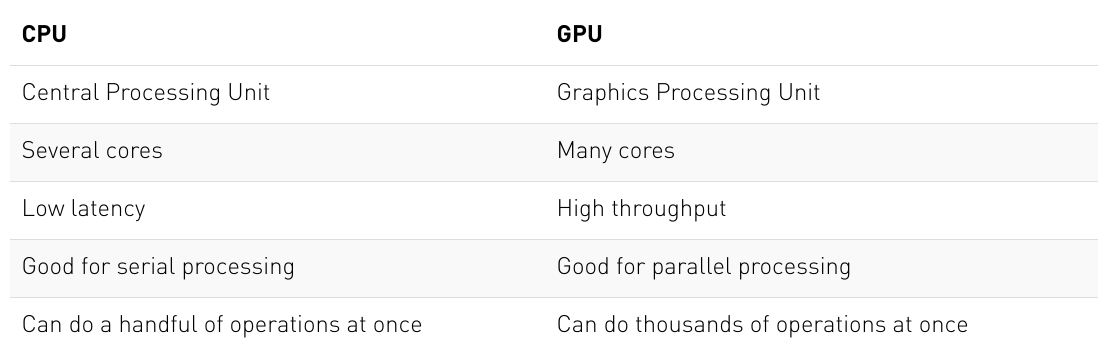

Comparaison du temps d'une grande multiplication matricielle CPU vs GPU. Sur GPU, CUDA étant asynchrone, on chronomètre avec `torch.cuda.Event`.

In [ ]:
big = torch.randn(1500, 1500)
t0 = time.time()
_ = torch.matmul(big, big)
print(f"matmul CPU : {time.time() - t0:.4f}s")

if torch.cuda.is_available():
    big_g = big.to(device)
    _ = torch.matmul(big_g, big_g)  # warm-up
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    _ = torch.matmul(big_g, big_g)
    end.record()
    torch.cuda.synchronize()
    print(f"matmul GPU : {0.001 * start.elapsed_time(end):.4f}s")

La graine CPU et la graine GPU sont distinctes : `set_seed` gère les deux (plus le déterminisme cuDNN).

In [ ]:
set_seed(42)

## 4. Cas synthétique : XOR continu

Le **XOR** n'est pas linéairement séparable : un neurone seul ne peut pas l'apprendre. On le rend continu en ajoutant un bruit gaussien aux entrées binaires. La génération est **identique** dans les trois notebooks (PyTorch / TF / Keras) pour pouvoir comparer.

continuous_xor.svg

In [ ]:
class XORDataset(data.Dataset):
    """Jeu XOR continu : 2 entrées binaires bruitées, label = XOR."""

    def __init__(self, size: int, std: float = 0.1) -> None:
        super().__init__()
        self.size = size
        self.std = std
        pts = torch.randint(0, 2, (size, 2), dtype=torch.float32)
        label = (pts.sum(dim=1) == 1).to(torch.long)
        pts = pts + std * torch.randn(pts.shape)
        self.data = pts
        self.label = label

    def __len__(self) -> int:
        return self.size

    def __getitem__(self, idx: int):
        return self.data[idx], self.label[idx]

Visualisons un échantillon : les deux classes (XOR=0 sur les coins (0,0)/(1,1), XOR=1 sur (0,1)/(1,0)).

In [ ]:
def visualize_samples(pts: torch.Tensor, label: torch.Tensor) -> None:
    pts_np = pts.cpu().numpy() if isinstance(pts, torch.Tensor) else pts
    lab_np = label.cpu().numpy() if isinstance(label, torch.Tensor) else label
    plt.figure(figsize=(4, 4))
    plt.scatter(pts_np[lab_np == 0, 0], pts_np[lab_np == 0, 1], edgecolor="#333", label="Classe 0")
    plt.scatter(pts_np[lab_np == 1, 0], pts_np[lab_np == 1, 1], edgecolor="#333", label="Classe 1")
    plt.title("Échantillons XOR")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.legend()
    plt.show()


xor_dataset = XORDataset(size=200)
visualize_samples(xor_dataset.data, xor_dataset.label)

## 5. Définition du modèle

Un réseau PyTorch est un `nn.Module` : on déclare les sous-modules dans `__init__` et le calcul dans `forward`. Ici une couche cachée `tanh`. **On ne met pas de sigmoïde finale** : la perte travaillera directement sur les *logits* (plus stable numériquement).

small_neural_network.svg

In [ ]:
class SimpleClassifier(nn.Module):
    """ANN minimal : Linear -> Tanh -> Linear (sortie en logits)."""

    def __init__(self, num_inputs: int, num_hidden: int, num_outputs: int) -> None:
        super().__init__()
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.Tanh()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(self.act_fn(self.linear1(x)))

On inspecte les paramètres : chaque `nn.Linear` a une matrice de poids `[sortie, entrée]` et un biais `[sortie]`.

In [ ]:
model = SimpleClassifier(2, 4, 1)
for name, param in model.named_parameters():
    print(f"{name}: {tuple(param.shape)}")

## 6. Données : Dataset et DataLoader

Le `DataLoader` itère sur un `Dataset` en gérant le *batching*, le *shuffle*, le chargement multi-process (`num_workers`) et le dernier lot incomplet (`drop_last`).

Sur Windows et pour de petits jeux, `num_workers=0` (défaut) est souvent le plus rapide.

In [ ]:
train_dataset = XORDataset(size=2500)
train_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True)

inp, lab = next(iter(train_loader))
print("batch inputs", tuple(inp.shape), "| labels", tuple(lab.shape))

## 7. Loss, optimiseur et scheduling

Pour la classification binaire on utilise l'**entropie croisée binaire** sur les logits, via `nn.BCEWithLogitsLoss` (combine sigmoïde + BCE de façon stable) :
$$\mathcal{L}_{BCE} = -\sum_i \left[ y_i \log \sigma(x_i) + (1 - y_i)\log(1 - \sigma(x_i)) \right].$$
L'optimiseur `SGD` met à jour les paramètres ; un *scheduler* (`StepLR`) réduit le taux d'apprentissage au fil des epochs.

In [ ]:
loss_module = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

## 8. Boucle d'entraînement standard

La boucle d'entraînement répète 5 étapes par lot : (1) envoyer au device, (2) forward, (3) calculer la perte, (4) `zero_grad` puis `backward`, (5) `optimizer.step`. On met le modèle en mode `train()`. Le `zero_grad` est crucial : sans lui, les gradients s'**ajoutent** d'un lot à l'autre.

In [ ]:
def train_model(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    data_loader: data.DataLoader,
    loss_module: nn.Module,
    num_epochs: int = 50,
    scheduler: torch.optim.lr_scheduler.LRScheduler | None = None,
) -> None:
    model.to(device)
    model.train()
    for _ in range(num_epochs):
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs).squeeze(dim=1)
            loss = loss_module(preds, labels.float())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()


train_model(model, optimizer, train_loader, loss_module, num_epochs=50, scheduler=scheduler)

**Bonne pratique 2026 — `torch.compile`.** Il compile le graphe du modèle (backend *inductor*) pour un gain de 20 à 50 %. `fullgraph=True` lève une erreur sur les *graph breaks* (utile pour diagnostiquer). La première exécution paie le coût de compilation. On l'enrobe d'un `try/except` car le backend peut être indisponible selon l'environnement (toolchain C absente, etc.).

In [ ]:
try:
    compiled_model = torch.compile(model)
    _ = compiled_model(torch.zeros(1, 2, device=device))
    print("torch.compile : modèle compilé")
except Exception as exc:
    print(f"torch.compile indisponible ici ({type(exc).__name__})")

## 9. Boucle manuelle et gestion fine du batch

Pour les jeux **déséquilibrés**, on veut contrôler finement la composition des lots. On illustre sur un jeu synthétique à 3 classes déséquilibrées (50 / 30 / 20 %).

In [ ]:
X_imb, y_imb = make_classification(
    n_samples=5000, n_features=10, n_informative=4, n_redundant=0,
    n_repeated=0, n_classes=3, n_clusters_per_class=1,
    weights=[0.5, 0.3, 0.2], random_state=42,
)
Xtr, Xval, ytr, yval = train_test_split(X_imb, y_imb, test_size=0.33, random_state=42)
Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
print("répartition des classes :", np.bincount(y_imb))

Deux briques utilitaires : un **sous-échantillonnage équilibré** (même nombre par classe) et un **tri round-robin** (0,1,2,0,1,2,...) en O(n) — version propre et typée des fonctions de l'original (qui étaient en O(n²) avec un `try/except` masquant les erreurs).

In [ ]:
def balanced_indices(y: np.ndarray, n_per_class: int) -> np.ndarray:
    """Indices sous-échantillonnés à n_per_class par classe (équilibré), mélangés."""
    classes = np.unique(y)
    picked = [np.random.choice(np.where(y == c)[0], n_per_class, replace=False) for c in classes]
    out = np.concatenate(picked)
    np.random.shuffle(out)
    return out


def round_robin_by_class(y: np.ndarray) -> np.ndarray:
    """Ordonne les indices en round-robin par classe (0,1,2,0,1,2,...). O(n)."""
    classes = np.unique(y)
    buckets = {c: list(np.where(y == c)[0]) for c in classes}
    order: list[int] = []
    remaining = sum(len(b) for b in buckets.values())
    while remaining:
        for c in classes:
            if buckets[c]:
                order.append(buckets[c].pop())
                remaining -= 1
    return np.array(order)


print("balanced labels :", np.bincount(ytr[balanced_indices(ytr, 5)]))
print("round-robin      :", ytr[:12][round_robin_by_class(ytr[:12])].tolist())

Une **boucle d'entraînement manuelle paramétrée** consolide les 4 variantes de l'original (équilibré/trié × par-nombre-de-batchs / par-taille-de-batch) en une seule fonction.

In [ ]:
def make_imb_model() -> nn.Module:
    return nn.Sequential(
        nn.Linear(10, 64), nn.ReLU(),
        nn.Linear(64, 32), nn.ReLU(),
        nn.Linear(32, 3),
    )


def manual_training_loop(
    X: np.ndarray, y: np.ndarray, Xv: np.ndarray, yv: np.ndarray,
    epochs: int = 8, mode: Literal["balanced", "sorted"] = "balanced",
    by: Literal["n_batches", "batch_size"] = "batch_size",
    n_batches: int = 9, batch_size: int = 32, n_per_class: int = 200,
) -> float:
    """Boucle manuelle paramétrée (équilibré/trié, nb-batch/taille-batch)."""
    model = make_imb_model().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    Xv_t = torch.tensor(Xv, dtype=torch.float32, device=device)
    yv_t = torch.tensor(yv, dtype=torch.long, device=device)
    for _ in range(epochs):
        idx = balanced_indices(y, n_per_class) if mode == "balanced" else round_robin_by_class(y)
        Xe = torch.tensor(X[idx], dtype=torch.float32, device=device)
        ye = torch.tensor(y[idx], dtype=torch.long, device=device)
        model.train()
        if by == "batch_size":
            for i in range(0, len(Xe), batch_size):
                opt.zero_grad()
                crit(model(Xe[i:i + batch_size]), ye[i:i + batch_size]).backward()
                opt.step()
        else:
            for s in torch.chunk(torch.arange(len(Xe)), n_batches):
                opt.zero_grad()
                crit(model(Xe[s]), ye[s]).backward()
                opt.step()
    model.eval()
    with torch.no_grad():
        return (model(Xv_t).argmax(1) == yv_t).float().mean().item()


acc_bal = manual_training_loop(Xtr, ytr, Xval, yval, mode="balanced", by="batch_size")
acc_sort = manual_training_loop(Xtr, ytr, Xval, yval, mode="sorted", by="n_batches")
print(f"équilibré/taille acc={acc_bal:.3f} | trié/nb-batch acc={acc_sort:.3f}")

La façon **idiomatique PyTorch** d'équilibrer sans réécrire de boucle : `WeightedRandomSampler`, qui sur-échantillonne les classes rares directement dans le `DataLoader`.

In [ ]:
class_counts = np.bincount(ytr)
sample_weights = (1.0 / class_counts)[ytr]
sampler = data.WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(ytr), replacement=True,
)
imb_ds = data.TensorDataset(Xtr_t, ytr_t)
balanced_loader = data.DataLoader(imb_ds, batch_size=64, sampler=sampler)

_xb, _yb = next(iter(balanced_loader))
print("batch équilibré (WeightedRandomSampler) :", np.bincount(_yb.numpy(), minlength=3))

## 10. Sauvegarde et chargement

On sauvegarde le `state_dict` (dictionnaire des paramètres) avec `torch.save`, et on le recharge dans un nouveau modèle avec `load_state_dict`. C'est la méthode recommandée (plus portable que sauver l'objet entier).

In [ ]:
torch.save(model.state_dict(), "xor_model.pt")

new_model = SimpleClassifier(2, 4, 1)
new_model.load_state_dict(torch.load("xor_model.pt"))

same = all(torch.equal(a, b) for a, b in zip(model.cpu().state_dict().values(),
                                             new_model.state_dict().values()))
print("paramètres identiques après rechargement :", same)
model.to(device)

## 11. Évaluation et métrique custom

En évaluation on passe en mode `eval()` (désactive dropout/batchnorm) et on coupe le graphe avec `torch.no_grad()` (mémoire + vitesse). L'accuracy :
$$acc = \frac{TP+TN}{TP+TN+FP+FN}.$$

In [ ]:
test_dataset = XORDataset(size=500)
test_loader = data.DataLoader(test_dataset, batch_size=128, shuffle=False, drop_last=False)


def eval_model(model: nn.Module, data_loader: data.DataLoader) -> float:
    model.eval()
    correct, total = 0.0, 0.0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = torch.sigmoid(model(inputs).squeeze(dim=1))
            correct += ((preds >= 0.5).long() == labels).sum().item()
            total += labels.shape[0]
    return correct / total


print(f"XOR accuracy : {eval_model(model, test_loader):.3f}")

**Frontière de décision (réintégré de l'original).** Pour *voir* ce que le réseau a appris, on prédit la classe sur une grille fine de $[-0{,}5, 1{,}5]^2$ et on colore chaque pixel par la probabilité prédite. Les quatre lobes du XOR doivent apparaître.

In [ ]:
@torch.no_grad()
def visualize_classification(model: nn.Module, pts: torch.Tensor, label: torch.Tensor):
    """Trace les points XOR + la frontière de décision apprise (grille de prédiction)."""
    pts_np = pts.cpu().numpy() if isinstance(pts, torch.Tensor) else pts
    lab_np = label.cpu().numpy() if isinstance(label, torch.Tensor) else label
    model = model.to(device)
    model.eval()

    fig = plt.figure(figsize=(4, 4))
    plt.scatter(pts_np[lab_np == 0, 0], pts_np[lab_np == 0, 1], edgecolor="#333", label="Classe 0")
    plt.scatter(pts_np[lab_np == 1, 0], pts_np[lab_np == 1, 1], edgecolor="#333", label="Classe 1")

    c0 = torch.tensor(to_rgba("C0"), device=device)
    c1 = torch.tensor(to_rgba("C1"), device=device)
    x1 = torch.arange(-0.5, 1.5, step=0.01, device=device)
    x2 = torch.arange(-0.5, 1.5, step=0.01, device=device)
    xx1, xx2 = torch.meshgrid(x1, x2, indexing="ij")
    grid = torch.stack([xx1, xx2], dim=-1)
    preds = torch.sigmoid(model(grid))                      # [H, W, 1]
    out = (1 - preds) * c0[None, None] + preds * c1[None, None]
    plt.imshow(out.cpu().numpy(), origin="lower", extent=(-0.5, 1.5, -0.5, 1.5))
    plt.grid(False)
    plt.title("Frontière de décision (XOR)")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.legend()
    plt.show()


visualize_classification(model, xor_dataset.data, xor_dataset.label)

**Métrique custom : F1 macro à la main.** En déséquilibre, l'accuracy est trompeuse ; on préfère le F1 macro (moyenne des F1 par classe). On le recalcule depuis la matrice de confusion, puis on vérifie contre `sklearn`.

In [ ]:
def f1_macro_manual(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """F1 macro recalculé à la main (precision/recall par classe)."""
    classes = np.unique(np.concatenate([y_true, y_pred]))
    f1s = []
    for c in classes:
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec = tp / (tp + fn) if (tp + fn) else 0.0
        f1s.append(2 * prec * rec / (prec + rec) if (prec + rec) else 0.0)
    return float(np.mean(f1s))


imb_model = make_imb_model().to(device)
opt_tmp = torch.optim.Adam(imb_model.parameters(), lr=1e-3)
for _ in range(5):
    for xb, yb in data.DataLoader(imb_ds, batch_size=128, shuffle=True):
        xb, yb = xb.to(device), yb.to(device)
        opt_tmp.zero_grad()
        F.cross_entropy(imb_model(xb), yb).backward()
        opt_tmp.step()

imb_model.eval()
with torch.no_grad():
    yval_pred = imb_model(torch.tensor(Xval, dtype=torch.float32, device=device)).argmax(1).cpu().numpy()

f1_manual = f1_macro_manual(yval, yval_pred)
f1_sklearn = f1_score(yval, yval_pred, average="macro")
print(f"F1 macro manuel={f1_manual:.4f} | sklearn={f1_sklearn:.4f}")

## 12. Gestion du déséquilibre

**Class weights.** `compute_class_weight("balanced", ...)` donne un poids par classe (inversement proportionnel à sa fréquence), passé en `weight=` de `nn.CrossEntropyLoss`.

In [ ]:
class_weights = compute_class_weight("balanced", classes=np.unique(ytr), y=ytr)
cw_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
crit_cw = nn.CrossEntropyLoss(weight=cw_tensor)

m_cw = make_imb_model().to(device)
opt_cw = torch.optim.Adam(m_cw.parameters(), lr=1e-3)
for _ in range(5):
    for xb, yb in data.DataLoader(imb_ds, batch_size=128, shuffle=True):
        xb, yb = xb.to(device), yb.to(device)
        opt_cw.zero_grad()
        crit_cw(m_cw(xb), yb).backward()
        opt_cw.step()
print("class weights :", np.round(class_weights, 3).tolist())

**Sample weights.** Pour pondérer chaque échantillon individuellement, on utilise `reduction="none"` (perte par échantillon) puis on multiplie par le poids avant de moyenner.

In [ ]:
sw = compute_sample_weight("balanced", ytr)
sw_t = torch.tensor(sw, dtype=torch.float32, device=device)
crit_none = nn.CrossEntropyLoss(reduction="none")

m_sw = make_imb_model().to(device)
opt_sw = torch.optim.Adam(m_sw.parameters(), lr=1e-3)
full_X, full_y = Xtr_t.to(device), ytr_t.to(device)
for _ in range(5):
    perm = torch.randperm(len(full_X))
    for i in range(0, len(full_X), 128):
        idx = perm[i:i + 128]
        opt_sw.zero_grad()
        (crit_none(m_sw(full_X[idx]), full_y[idx]) * sw_t[idx]).mean().backward()
        opt_sw.step()
print("sample weights min/max :", round(sw.min(), 3), round(sw.max(), 3))

**Focal loss.** Elle réduit le poids des exemples bien classés pour se concentrer sur les difficiles :
$$FL(p_t) = -\alpha\,(1 - p_t)^{\gamma}\,\log(p_t),$$
où $p_t$ est la probabilité de la bonne classe et $\gamma$ le facteur de focalisation.

In [ ]:
def focal_loss(logits: torch.Tensor, targets: torch.Tensor,
               gamma: float = 2.0, alpha: float | None = None) -> torch.Tensor:
    """Focal loss multi-classes : FL = -alpha (1-p_t)^gamma log(p_t)."""
    log_p = F.log_softmax(logits, dim=1)
    log_pt = log_p.gather(1, targets.unsqueeze(1)).squeeze(1)
    pt = log_pt.exp()
    loss = -((1 - pt) ** gamma) * log_pt
    if alpha is not None:
        loss = alpha * loss
    return loss.mean()


m_fl = make_imb_model().to(device)
opt_fl = torch.optim.Adam(m_fl.parameters(), lr=1e-3)
for _ in range(5):
    for xb, yb in data.DataLoader(imb_ds, batch_size=128, shuffle=True):
        xb, yb = xb.to(device), yb.to(device)
        opt_fl.zero_grad()
        focal_loss(m_fl(xb), yb, gamma=2.0).backward()
        opt_fl.step()

m_fl.eval()
with torch.no_grad():
    fl_pred = m_fl(torch.tensor(Xval, dtype=torch.float32, device=device)).argmax(1).cpu().numpy()
print(f"focal loss — F1 macro val = {f1_score(yval, fl_pred, average='macro'):.3f}")

## 13. Régularisation

Panorama des techniques pour limiter le surapprentissage :

- **Dropout** (`nn.Dropout`) : désactive aléatoirement des neurones à l'entraînement.
- **Batch norm** (`nn.BatchNorm1d`) : normalise les activations, stabilise et accélère.
- **Weight decay** (régularisation L2) : passé en argument de l'optimiseur.
- **Early stopping** : arrêt quand la perte de validation cesse de progresser.

Important : le dropout/batchnorm se placent **entre couches cachées**, pas après la couche de sortie.

In [ ]:
class RegularizedNet(nn.Module):
    """Dropout + BatchNorm entre couches cachées (pas en sortie)."""

    def __init__(self, in_dim: int, n_classes: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.drop = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.drop(F.relu(self.bn1(self.fc1(x))))
        return self.fc2(x)


reg_model = RegularizedNet(10, 3).to(device)
reg_opt = torch.optim.Adam(reg_model.parameters(), lr=1e-3, weight_decay=1e-4)  # weight decay = L2
for _ in range(5):
    for xb, yb in data.DataLoader(imb_ds, batch_size=128, shuffle=True):
        xb, yb = xb.to(device), yb.to(device)
        reg_opt.zero_grad()
        F.cross_entropy(reg_model(xb), yb).backward()
        reg_opt.step()
print("modèle régularisé entraîné")

Helper `EarlyStopping` réutilisé pour les cas réels (mémorise le meilleur état du modèle).

In [ ]:
class EarlyStopping:
    """Early stopping sur la loss de validation (patience)."""

    def __init__(self, patience: int = 10) -> None:
        self.patience = patience
        self.best = np.inf
        self.counter = 0
        self.best_state: dict | None = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best:
            self.best = val_loss
            self.counter = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

## 14. Logging avec TensorBoard

`SummaryWriter` écrit des journaux que TensorBoard visualise : `add_scalar` (courbes), `add_graph` (graphe du modèle), `add_figure` (figures matplotlib).

In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("runs/xor_experiment")
tb_model = SimpleClassifier(2, 4, 1).to(device)
tb_opt = torch.optim.SGD(tb_model.parameters(), lr=0.1)
for epoch in range(10):
    epoch_loss = 0.0
    tb_model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        loss = loss_module(tb_model(inputs).squeeze(dim=1), labels.float())
        tb_opt.zero_grad()
        loss.backward()
        tb_opt.step()
        epoch_loss += loss.item()
    writer.add_scalar("training_loss", epoch_loss / len(train_loader), epoch + 1)
writer.close()
print("journaux TensorBoard écrits dans runs/xor_experiment")

Pour lancer l'interface TensorBoard, exécuter dans une cellule du notebook les magics Jupyter `%load_ext tensorboard` puis `%tensorboard --logdir runs` (non incluses ici car ce sont des commandes Jupyter, pas du Python exécutable hors notebook).

## 15. Cas réel — Classification MNIST

MNIST (chiffres manuscrits 28×28) via `torchvision`. `ToTensor()` ramène les pixels dans [0,1]. On **sous-échantillonne** (8000 train / 2000 test) pour un entraînement rapide sur CPU.

In [ ]:
tfm = transforms.Compose([transforms.ToTensor()])
mnist_train_full = torchvision.datasets.MNIST("data_mnist", train=True, download=True, transform=tfm)
mnist_test_full = torchvision.datasets.MNIST("data_mnist", train=False, download=True, transform=tfm)

set_seed(42)
tr_idx = np.random.choice(len(mnist_train_full), 8000, replace=False)
te_idx = np.random.choice(len(mnist_test_full), 2000, replace=False)
mnist_train = data.Subset(mnist_train_full, tr_idx.tolist())
mnist_test = data.Subset(mnist_test_full, te_idx.tolist())
mnist_train_loader = data.DataLoader(mnist_train, batch_size=128, shuffle=True)
mnist_test_loader = data.DataLoader(mnist_test, batch_size=256, shuffle=False)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    img, lbl = mnist_train_full[i]
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(str(lbl))
    axes[i].axis("off")
plt.show()

Deux architectures : un **ANN** (perceptron multicouche sur l'image aplatie) et un **CNN** (convolutions, naturel pour les images).

In [ ]:
class MNIST_ANN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class MNIST_CNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(32 * 7 * 7, 10))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.conv(x))

Fonctions d'entraînement et d'accuracy réutilisables, puis entraînement court des deux modèles.

In [ ]:
def train_classifier(model: nn.Module, loader: data.DataLoader, epochs: int = 2) -> nn.Module:
    model.to(device).train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            F.cross_entropy(model(xb), yb).backward()
            opt.step()
    return model


def accuracy(model: nn.Module, loader: data.DataLoader) -> float:
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / total


ann = train_classifier(MNIST_ANN(), mnist_train_loader, epochs=3)
cnn = train_classifier(MNIST_CNN(), mnist_train_loader, epochs=2)
print(f"ANN acc={accuracy(ann, mnist_test_loader):.3f} | CNN acc={accuracy(cnn, mnist_test_loader):.3f}")

**Matrice de confusion** du CNN sur le jeu de test.

In [ ]:
cnn.eval()
all_logits, all_true = [], []
with torch.no_grad():
    for xb, yb in mnist_test_loader:
        all_logits.append(cnn(xb.to(device)).cpu())
        all_true.append(yb)
logits = torch.cat(all_logits)
y_true = torch.cat(all_true).numpy()
probs = F.softmax(logits, dim=1).numpy()
y_pred = probs.argmax(1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Vrai")
plt.title("Matrice de confusion MNIST (CNN)")
plt.show()

**ROC / AUC one-vs-rest macro.** MNIST a 10 classes : on calcule une courbe ROC par classe (chaque classe contre le reste) à partir des **probabilités** (softmax sous `eval()`/`no_grad()`), et on résume par l'AUC macro.

In [ ]:
y_onehot = np.eye(10)[y_true]
plt.figure(figsize=(6, 6))
for c in range(10):
    fpr, tpr, _ = roc_curve(y_onehot[:, c], probs[:, c])
    plt.plot(fpr, tpr, lw=0.8, alpha=0.6)
plt.plot([0, 1], [0, 1], "k--")
macro_auc = roc_auc_score(y_onehot, probs, average="macro")
plt.title(f"ROC one-vs-rest MNIST (macro AUC={macro_auc:.3f})")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.show()
print(f"AUC macro = {macro_auc:.3f}")

**Bonus — RNN/LSTM.** On peut traiter l'image comme une séquence de 28 lignes de 28 pixels. C'est plus un exercice qu'une bonne pratique pour des images (le CNN reste l'archi naturelle), et la précision reste basse avec peu d'epochs.

In [ ]:
class MNIST_RNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.rnn = nn.LSTM(input_size=28, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.squeeze(1)  # [B, 28, 28] = (batch, seq, feat)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1])


rnn = train_classifier(MNIST_RNN(), mnist_train_loader, epochs=3)
print(f"bonus LSTM acc={accuracy(rnn, mnist_test_loader):.3f}")

## 16. Cas réel — Régression California Housing

California Housing (`sklearn`) remplace l'ancien dataset Boston (retiré pour raisons éthiques). On standardise les features, on découpe train/test et on construit des `TensorDataset`.

In [ ]:
cal = fetch_california_housing()
Xc = StandardScaler().fit_transform(cal.data)
yc = cal.target.astype(np.float32)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42)

cal_train = data.TensorDataset(torch.tensor(Xc_tr, dtype=torch.float32),
                               torch.tensor(yc_tr, dtype=torch.float32).view(-1, 1))
cal_test = data.TensorDataset(torch.tensor(Xc_te, dtype=torch.float32),
                              torch.tensor(yc_te, dtype=torch.float32).view(-1, 1))
cal_train_loader = data.DataLoader(cal_train, batch_size=64, shuffle=True)
cal_test_loader = data.DataLoader(cal_test, batch_size=256, shuffle=False)

Modèle de régression avec dropout **entre couches cachées seulement** (l'original appliquait à tort un dropout après la couche de sortie).

In [ ]:
class RegressionModel(nn.Module):
    """Régression : dropout entre couches cachées seulement."""

    def __init__(self, in_dim: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.drop = nn.Dropout(0.1)
        self.fc2 = nn.Linear(64, 1)  # pas de dropout après la sortie

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.drop(F.relu(self.fc1(x))))

Entraînement avec **early stopping**, en logguant la perte **moyenne par epoch** (l'original logguait par erreur la perte du dernier batch).

In [ ]:
reg = RegressionModel(Xc.shape[1]).to(device)
reg_opt = torch.optim.Adam(reg.parameters(), lr=0.01)
mse = nn.MSELoss()
stopper = EarlyStopping(patience=10)
train_losses, test_losses = [], []

for epoch in range(100):
    reg.train()
    running = 0.0
    for xb, yb in cal_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        reg_opt.zero_grad()
        loss = mse(reg(xb), yb)
        loss.backward()
        reg_opt.step()
        running += loss.item()
    train_losses.append(running / len(cal_train_loader))

    reg.eval()
    vloss = 0.0
    with torch.no_grad():
        for xb, yb in cal_test_loader:
            xb, yb = xb.to(device), yb.to(device)
            vloss += mse(reg(xb), yb).item()
    test_losses.append(vloss / len(cal_test_loader))
    if stopper.step(test_losses[-1], reg):
        print(f"early stopping epoch {epoch + 1}")
        break

if stopper.best_state is not None:
    reg.load_state_dict(stopper.best_state)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("California Housing — pertes")
plt.legend()
plt.show()

Métriques de régression : RMSE, MAE et R².

In [ ]:
reg.eval()
with torch.no_grad():
    yc_hat = reg(torch.tensor(Xc_te, dtype=torch.float32, device=device)).cpu().numpy().ravel()
rmse = float(np.sqrt(mean_squared_error(yc_te, yc_hat)))
mae = float(mean_absolute_error(yc_te, yc_hat))
r2 = float(r2_score(yc_te, yc_hat))
print(f"RMSE={rmse:.3f} | MAE={mae:.3f} | R2={r2:.3f}")

## 17. Explicabilité avec SHAP

SHAP attribue à chaque pixel sa contribution à la prédiction. Côté PyTorch, `DeepExplainer` fonctionne bien (contrairement à TF/Keras 3 où il faut `GradientExplainer`). On fournit un jeu d'arrière-plan (*background*) pour l'espérance de référence, puis on explique quelques images de test.

Note : on bloque l'import de TensorFlow avant `shap`, car avoir torch et tensorflow chargés dans le même process peut provoquer un crash ; shap fonctionne en mode torch-only.

In [ ]:
import sys
sys.modules.setdefault("tensorflow", None)  # SHAP en mode torch-only (évite le conflit torch/tf)
import shap

bg_imgs = torch.stack([mnist_train_full[int(i)][0] for i in tr_idx[:50]]).to(device)
test_imgs = torch.stack([mnist_test_full[int(i)][0] for i in te_idx[:3]]).to(device)

cnn.eval()
explainer = shap.DeepExplainer(cnn, bg_imgs)
shap_values = explainer.shap_values(test_imgs, check_additivity=False)

On met en forme les valeurs SHAP au format attendu par `image_plot` (images en dernier axe pour les canaux) et on affiche les attributions par classe.

In [ ]:
# DeepExplainer renvoie soit une liste (1 array (n,1,28,28) par classe),
# soit un seul ndarray (n, 1, 28, 28, n_classes). On ramène le canal en dernier
# (-> (n, 28, 28, 1)) et on produit une carte d'attribution par classe (0-9).
if isinstance(shap_values, list):
    shap_numpy = [np.moveaxis(s, 1, -1) for s in shap_values]
else:
    sv = np.asarray(shap_values)
    shap_numpy = [np.moveaxis(sv[..., k], 1, -1) for k in range(sv.shape[-1])]
test_numpy = np.moveaxis(test_imgs.cpu().numpy(), 1, -1)

# Chaque ligne = une image de test ; les 10 colonnes = attributions pour les classes 0-9.
shap.image_plot(shap_numpy, test_numpy)

## Sources et pour aller plus loin

- Tutoriel d'origine : *UvA Deep Learning Tutorials* (introduction à PyTorch).
- Documentation officielle : [pytorch.org](https://pytorch.org/) et ses [tutoriels](https://pytorch.org/tutorials/).
- Techniques avancées (batch manuel, class/sample weights, SHAP) adaptées d'un notebook TensorFlow/Keras vers les idiomes PyTorch.
- Notebooks frères de la série : `DL_TensorFlow` (bas niveau, `tf.GradientTape`) et `DL_Keras` (haut niveau multi-backend), plus le comparatif `DL_Frameworks_Comparatif`.